 Capillary Bridge Force Analysis Notebook

# 1. Setup & Imports

In [1]:
import sys
from pathlib import Path
import json
from pprint import pprint

cfg = json.load(open(r"Analysis_Files\config.json"))
image_dir = Path(cfg["image_dir"])
mask_dir  = Path(cfg["mask_dir"])
output_dir = Path(cfg["output_dir"])
lines_file = Path(cfg["lines_file"])
label_clf = Path(cfg["label_clf_path"])
side_clf  = Path(cfg["side_clf_path"])
excel_out = Path(cfg["output_dir"]) / cfg["excel_output"]
debug_dir = Path(cfg["output_dir"]) / cfg["debug_image_dir"]
first_frame_spacing = cfg["first_frame_spacing"]
sigma_surface_tension = cfg["sigma_surface_tension"]
pprint(cfg)

{'debug_image_dir': 'E:\\Capillary_bridging_data_alannah\\Silane Capillary '
                    'Action\\3bromoSilane_glassone_dynamic\\Output\\debug_images',
 'excel_output': 'Alannah_S1_training.xlsx',
 'first_frame_spacing': 5e-05,
 'image_dir': 'E:\\Capillary_bridging_data_alannah\\Silane Capillary '
              'Action\\3bromoSilane_glassone_dynamic',
 'label_clf_path': 'Analysis_Files\\Classifier_files\\trained_classifiers\\mask_edge_classifier3.pkl',
 'lines_file': 'E:\\Capillary_bridging_data_alannah\\Silane Capillary '
               'Action\\3bromoSilane_glassone_dynamic\\Output\\Alannah_S1_substrates.npz',
 'mask_dir': 'E:\\Capillary_bridging_data_alannah\\Silane Capillary '
             'Action\\3bromoSilane_glassone_dynamic\\masks_json',
 'output_dir': 'E:\\Capillary_bridging_data_alannah\\Silane Capillary '
               'Action\\3bromoSilane_glassone_dynamic\\Output',
 'side_clf_path': 'Analysis_Files\\Classifier_files\\trained_classifiers\\contour_side_classifier3.p

In [2]:
#select new image folder path,and mask folder path, and output folder path
import tkinter as tk
from tkinter import filedialog
root = tk.Tk()
root.withdraw()  # Hide the root window
#keep the dialong on top
root.attributes('-topmost', True)

image_dir = Path(filedialog.askdirectory(title="Select Image Folder", initialdir=image_dir))
mask_dir = Path(filedialog.askdirectory(title="Select Mask Folder", initialdir=image_dir))
output_dir = Path(filedialog.askdirectory(title="Select Output Folder", initialdir=image_dir))
lines_file = output_dir / "Alannah_S1_substrates.npz"
debug_dir = output_dir / "debug_images"
#rewrite the config file with the new paths
cfg["image_dir"] = str(image_dir)
cfg["mask_dir"] = str(mask_dir)
cfg["output_dir"] = str(output_dir)
cfg["lines_file"] = str(lines_file)
cfg["debug_image_dir"] = str(debug_dir)
with open("Analysis_Files/config.json", "w") as f:
    json.dump(cfg, f, indent=4)
print(f"Image directory set to: {image_dir}")
print(f"Mask directory set to: {mask_dir}")
print(f"Output directory set to: {output_dir}")

Image directory set to: E:\Capillary_bridging_data_alannah\Silane Capillary Action\3bromoSilane_glassone_dynamic
Mask directory set to: E:\Capillary_bridging_data_alannah\Silane Capillary Action\3bromoSilane_glassone_dynamic\masks_json
Output directory set to: E:\Capillary_bridging_data_alannah\Silane Capillary Action\3bromoSilane_glassone_dynamic\Output


# 2. Define Substrate Lines

In [4]:
%matplotlib qt
%run Analysis_Files\Substrate_tests\define_substrate_lines.py


Use the slider to browse frames. Click 'Select/Unselect' to mark important frames. Click 'Done' when finished.


KeyboardInterrupt: 

In [7]:
cfg = json.load(open(r"Analysis_Files\config.json"))
image_dir = Path(cfg["image_dir"])
mask_dir  = Path(cfg["mask_dir"])
output_dir = Path(cfg["output_dir"])
lines_file = Path(cfg["lines_file"])
label_clf = Path(cfg["label_clf_path"])
side_clf  = Path(cfg["side_clf_path"])
excel_out = Path(cfg["output_dir"]) / cfg["excel_output"]
debug_dir = Path(cfg["output_dir"]) / cfg["debug_image_dir"]
first_frame_spacing = cfg["first_frame_spacing"]
sigma_surface_tension = cfg["sigma_surface_tension"]
pprint(cfg)

{'debug_image_dir': 'E:\\Capillary_bridging_data_alannah\\Silane Capillary '
                    'Action\\3bromoSilane_glassone_dynamic\\Output\\debug_images',
 'excel_output': 'Alannah_S1_training.xlsx',
 'first_frame_spacing': 5e-05,
 'image_dir': 'E:\\Capillary_bridging_data_alannah\\Silane Capillary '
              'Action\\3bromoSilane_glassone_dynamic',
 'label_clf_path': 'Analysis_Files\\Classifier_files\\trained_classifiers\\mask_edge_classifier3.pkl',
 'lines_file': 'E:\\Capillary_bridging_data_alannah\\Silane Capillary '
               'Action\\3bromoSilane_glassone_dynamic\\Output\\Alannah_S1_substrates.npz',
 'mask_dir': 'E:\\Capillary_bridging_data_alannah\\Silane Capillary '
             'Action\\3bromoSilane_glassone_dynamic\\masks_json',
 'output_dir': 'E:\\Capillary_bridging_data_alannah\\Silane Capillary '
               'Action\\3bromoSilane_glassone_dynamic\\Output',
 'side_clf_path': 'Analysis_Files\\Classifier_files\\trained_classifiers\\contour_side_classifier3.p

In [1]:
%matplotlib qt
%run Analysis_Files\Substrate_tests\view_substrate_lines.py

# 3. Run force analysis

In [5]:
%run -i Analysis_Files\plot_forces_multiprocessing.py

Found 60 images in E:\Capillary_bridging_data_alannah\Silane Capillary Action\3bromoSilane_glassone_dynamic


100%|██████████| 60/60 [00:40<00:00,  1.48it/s]



✅ Results saved to: E:\Capillary_bridging_data_alannah\Silane Capillary Action\3bromoSilane_glassone_dynamic\Output\Alannah_S1_training.xlsx


# 4. Display Final Plot

C:\Users\raglo\OneDrive - University of Arizona\Documents\GitHub\Capillary_Liquid_Bridges\Analysis_Files\Plot_from_excel.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', n_segments +1)


Plot saved to: E:\Capillary_bridging_data_alannah\Silane Capillary Action\3bromoSilane_glassone_dynamic\Output\capillary_bridge_forces_vs_plate_separation.png


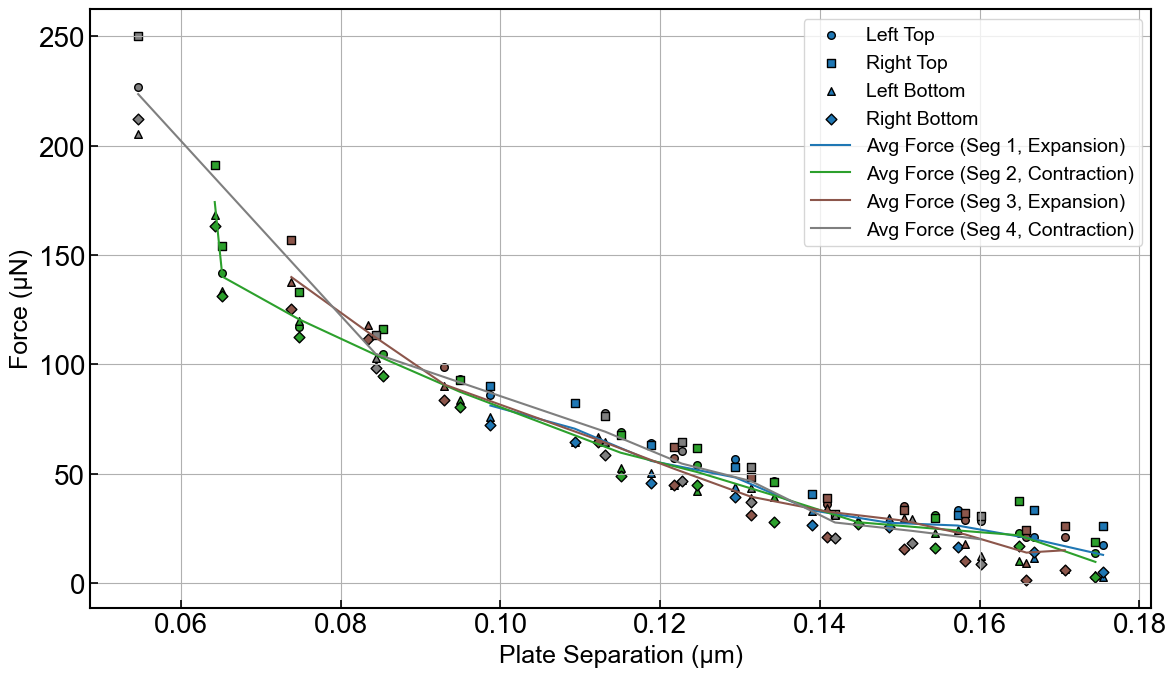

<Figure size 640x480 with 0 Axes>

In [10]:
%matplotlib inline
%run -i Analysis_Files/Plot_from_excel.py